In [1]:
from typing import TypedDict

class ConversionState(TypedDict):
    amount_usd: float
    convert_to: str
    amount_inr: float
    amount_lkr: float

In [2]:
def convert_to_inr(state: ConversionState) -> ConversionState:
    state["amount_inr"] = state["amount_usd"] * 95.69
    return state

def convert_to_lkr(state: ConversionState) -> ConversionState:
    state["amount_lkr"] = state["amount_usd"] * 323.06
    return state

def add_conversion_currency(state: ConversionState) -> str:
    return state["convert_to"]

In [6]:
from langgraph.graph import START, END, StateGraph

builder = StateGraph(ConversionState)

builder.add_node("convert_to_inr_node", convert_to_inr)
builder.add_node("convert_to_lkr_node", convert_to_lkr)

builder.add_conditional_edges(
    START, 
    add_conversion_currency, 
    {
        "lkr": "convert_to_lkr_node",
        "inr": "convert_to_inr_node"
    }
)
builder.add_edge("convert_to_inr_node", END)
builder.add_edge("convert_to_lkr_node", END)

graph = builder.compile()

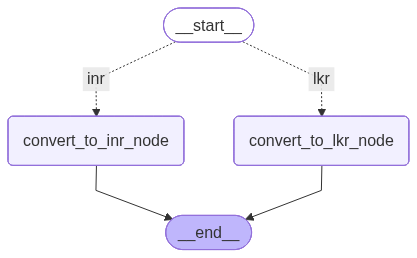

In [7]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
graph.invoke({
    "amount_usd": 1.00,
    "convert_to": "inr"
})

{'amount_usd': 1.0, 'convert_to': 'inr', 'amount_inr': 95.69}

In [10]:
graph.invoke({
    "amount_usd": 1.00,
    "convert_to": "lkr"
})

{'amount_usd': 1.0, 'convert_to': 'lkr', 'amount_lkr': 323.06}